Saved: delivery_environment.png


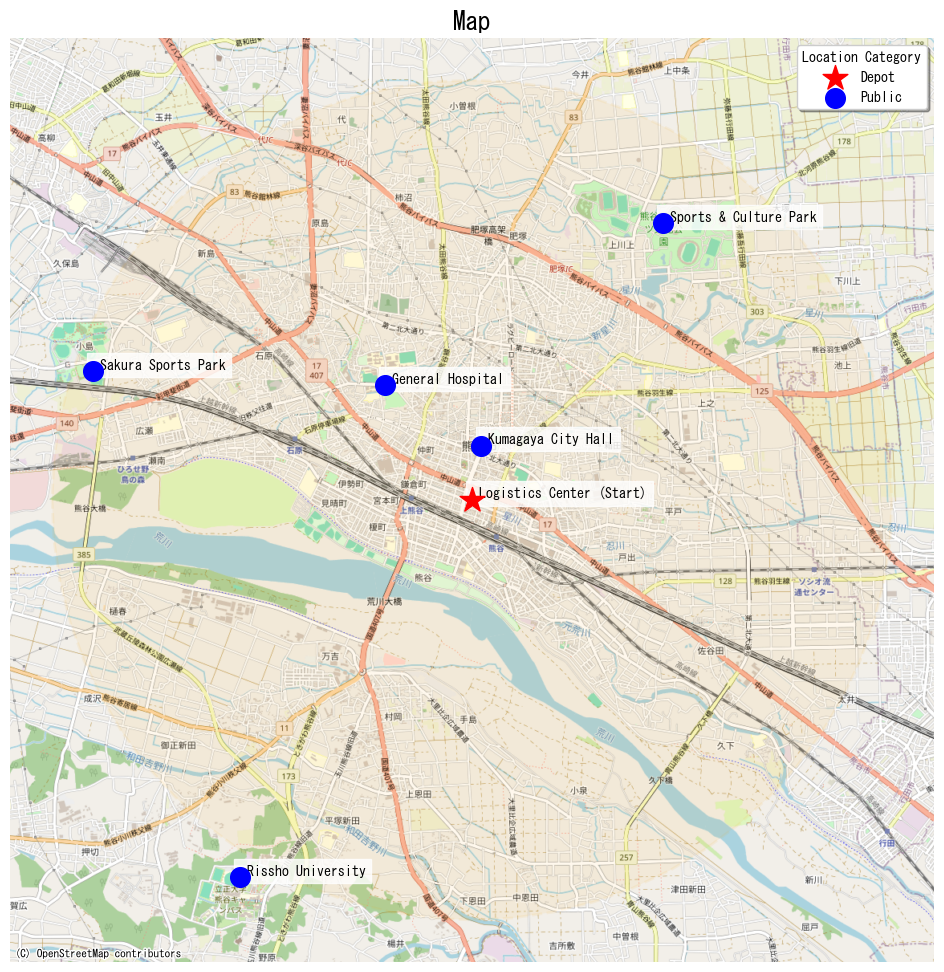

In [14]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx

# 1. 公開用地点データの再定義
data = {
    'Name': [
        'Logistics Center (Start)', # 拠点
        'Kumagaya City Hall',       # 熊谷市役所
        'Sports & Culture Park',    # スポーツ文化公園
        'General Hospital',         # 熊谷総合病院
        'Sakura Sports Park',       # 熊谷さくら運動公園(36.15361767216999, 139.34723652610023)
        'Rissho University'         # 立正大学（熊谷キャンパス）
    ],
    'Lat': [36.1425, 36.1472, 36.1664, 36.1524, 36.15361767216999, 36.10991],
    'Lon': [139.3878, 139.3888, 139.4082, 139.3785, 139.34723652610023, 139.36295],
    'Type': ['Depot', 'Public', 'Public', 'Public', 'Public', 'Public']
}

df = pd.DataFrame(data)

# 2. GeoDataFrameの作成と座標変換
gdf = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df.Lon, df.Lat), crs="EPSG:4326"
)
gdf = gdf.to_crs(epsg=3857)

# 3. プロットの作成
fig, ax = plt.subplots(figsize=(12, 12))

# 種類ごとの色分け設定
colors = {'Depot': 'red', 'Public': 'blue', 'University': 'purple'}
markers = {'Depot': '*', 'Public': 'o', 'University': '^'}

for t in df['Type'].unique():
    mask = gdf['Type'] == t
    gdf[mask].plot(ax=ax, color=colors[t], marker=markers[t], 
                   markersize=350 if t=='Depot' else 200, 
                   label=t, zorder=5)

# ラベルの追加（視認性を高めるため背景白）
for x, y, label in zip(gdf.geometry.x, gdf.geometry.y, gdf['Name']):
    ax.annotate(f" {label}", xy=(x, y), fontsize=10, fontweight='bold', 
                backgroundcolor='#FFFFFFCC', verticalalignment='bottom')

# 4. 行動領域（半径5km）の描画
center_pt = gdf.iloc[0].geometry
circle = center_pt.buffer(5000) 
gpd.GeoSeries([circle], crs=3857).plot(ax=ax, color='orange', alpha=0.07, 
                                        edgecolor='orange', linestyle='--', linewidth=2)

# 5. 背景地図の追加
cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)

# iamgesの保存と表示
ax.set_axis_off()
plt.legend(title="Location Category", loc='upper right', shadow=True)

# 保存
plt.savefig("delivery_environment.png", bbox_inches='tight', dpi=300)
print("Saved: delivery_environment.png")
plt.show()

In [9]:
import requests
import pandas as pd
import numpy as np

# 1. 前のセルで定義したデータから座標と名前を抽出
# OSRM APIは {longitude},{latitude} の順で指定する必要があります
names = data['Name']
coords_list = [f"{lon},{lat}" for lat, lon in zip(data['Lat'], data['Lon'])]
coords_query = ";".join(coords_list)

# 2. OSRM Table APIへのリクエストURL作成
# annotations=distance を指定することで走行距離（メートル）を取得します
url = f"http://router.project-osrm.org/table/v1/driving/{coords_query}?annotations=distance"

print("Fetching distance matrix from OSRM...")

try:
    response = requests.get(url)
    res_data = response.json()

    if res_data['code'] == 'Ok':
        # 3. 取得した距離行列をDataFrameに変換
        # 行名(index)と列名(columns)に地点名を設定
        dist_matrix = pd.DataFrame(res_data['distances'], index=names, columns=names)
        
        # 整数値（メートル）に丸める
        dist_matrix = dist_matrix.round(0).astype(int)
        
        print("\n--- 走行距離行列 (Road Distance Matrix in meters) ---")
        print(dist_matrix)
        
        # 4. CSVファイルとして保存（後続の最適化計算で使用）
        dist_matrix.to_csv("distance_matrix.csv", encoding='utf-8-sig')
        print("\nSaved: distance_matrix.csv")
    else:
        print(f"Error from API: {res_data['code']}")

except Exception as e:
    print(f"An error occurred: {e}")

Fetching distance matrix from OSRM...

--- 走行距離行列 (Road Distance Matrix in meters) ---
                          Logistics Center (Start)  Kumagaya City Hall  \
Logistics Center (Start)                         0                 679   
Kumagaya City Hall                             611                   0   
Sports & Culture Park                         4086                4562   
General Hospital                              1853                1385   
Sakura Sports Park                            4876                4672   
Rissho University                             6192                6324   

                          Sports & Culture Park  General Hospital  \
Logistics Center (Start)                   4133              1824   
Kumagaya City Hall                         4592              1315   
Sports & Culture Park                         0              4516   
General Hospital                           4516                 0   
Sakura Sports Park                         7958  

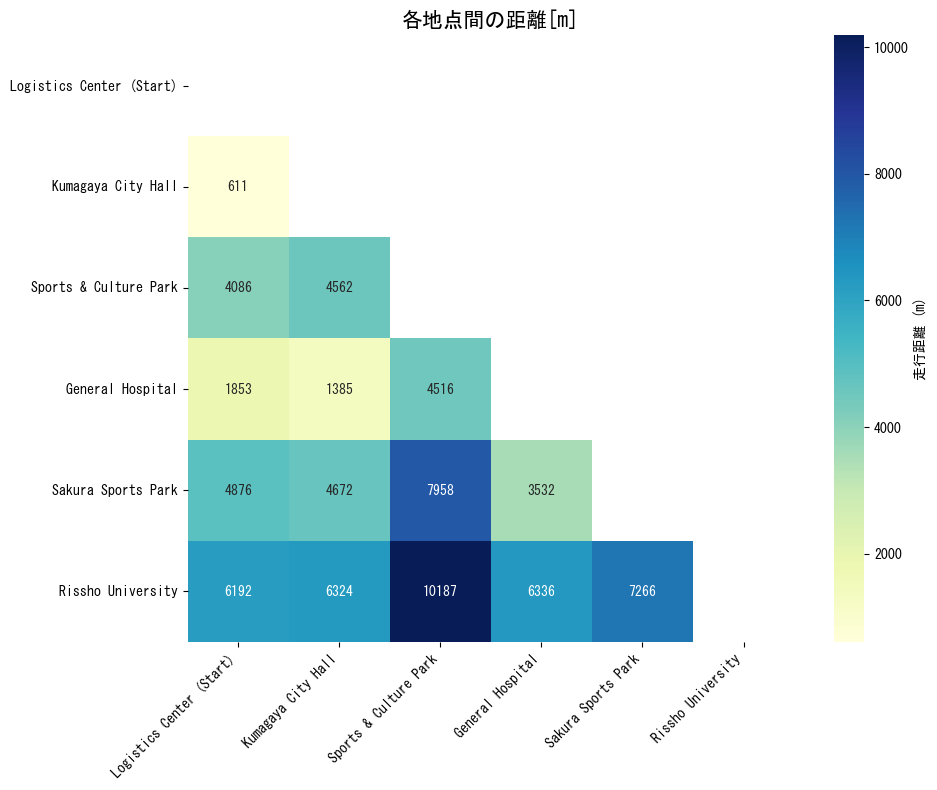

In [12]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 日本語フォント設定
plt.rcParams['font.family'] = 'MS Gothic' 

# 対角成分と上半分を隠すためのマスクを作成
mask = np.triu(np.ones_like(dist_matrix, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(dist_matrix, mask=mask, annot=True, fmt="d", cmap="YlGnBu", 
            cbar_kws={'label': '走行距離 (m)'}, square=True)

plt.title("各地点間の距離[m]", fontsize=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig("distance_map.png", dpi=300)
plt.show()

In [17]:
import pulp

# 1. 問題の定義
# 名前を "TSP_Kumagaya" とし、最小化問題 (LpMinimize) を指定
prob = pulp.LpProblem("TSP_Kumagaya", pulp.LpMinimize)

# 2. 定数・集合の定義
n = len(dist_matrix)
nodes = dist_matrix.index.tolist()

# 3. 決定変数の定義
# x[i,j] はバイナリ変数
x = pulp.LpVariable.dicts("x", (nodes, nodes), cat='Binary')
# u[i] は連続変数（部分巡回除去用）
u = pulp.LpVariable.dicts("u", nodes, lowBound=0, upBound=n-1, cat='Continuous')

# 4. 目的関数の追加
prob += pulp.lpSum(dist_matrix.loc[i, j] * x[i][j] for i in nodes for j in nodes if i != j)

# 5. 制約条件の追加
# (1) 各地点を1回出発
for i in nodes:
    prob += pulp.lpSum(x[i][j] for j in nodes if i != j) == 1

# (2) 各地点に1回到着
for j in nodes:
    prob += pulp.lpSum(x[i][j] for i in nodes if i != j) == 1

# (3) MTZ制約（部分巡回除去）
depot = nodes[0]
for i in nodes:
    for j in nodes:
        if i != depot and j != depot and i != j:
            prob += u[i] - u[j] + n * x[i][j] <= n - 1

# 6. ソルバーの実行
status = prob.solve()

# 7. 結果の表示
print(f"Status: {pulp.LpStatus[status]}")
if status == pulp.LpStatusOptimal:
    print(f"Total Distance: {pulp.value(prob.objective):.1f} m")
    
    # ルートの抽出（ここを修正しました）
    curr_node = depot
    route = [curr_node]
    while True:
        next_node = None
        for j in nodes:
            # 現在の地点(curr_node)から次(j)への移動が1であるものを探す
            if curr_node != j and pulp.value(x[curr_node][j]) >= 0.9: # 1.0に近いか判定
                next_node = j
                break
        
        if next_node is None or next_node == depot:
            break
            
        route.append(next_node)
        curr_node = next_node
    
    print("Optimal Route:", " -> ".join(route), "->", depot)

Status: Optimal
Total Distance: 25927.0 m
Optimal Route: Logistics Center (Start) -> Sports & Culture Park -> General Hospital -> Sakura Sports Park -> Rissho University -> Kumagaya City Hall -> Logistics Center (Start)
